# Lab 5 — Mushroom Classification: Edible vs Poisonous

**Dataset:** UCI Mushroom Dataset — 8,124 rows, 22 features
**Problem:** Binary Classification — `edible` vs `poisonous`
**Target:** `class`

Misidentifying a poisonous mushroom as edible can be fatal. That's why **Recall** (catching every poisonous mushroom) is the metric we care about most — a false negative here could kill someone, while a false positive just wastes a mushroom.

## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. Data Inspection

In [2]:
df = pd.read_csv('mushrooms.csv')
print('Shape:', df.shape)
df.info()

Shape: (8124, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-

In [3]:
df.head(10)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,e,e,s,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,e,c,s,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,e,c,s,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,e,e,s,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,t,e,s,s,w,w,p,w,o,e,n,a,g
5,e,x,y,y,t,a,f,c,b,n,e,c,s,s,w,w,p,w,o,p,k,n,g
6,e,b,s,w,t,a,f,c,b,g,e,c,s,s,w,w,p,w,o,p,k,n,m
7,e,b,y,w,t,l,f,c,b,n,e,c,s,s,w,w,p,w,o,p,n,s,m
8,p,x,y,w,t,p,f,c,n,p,e,e,s,s,w,w,p,w,o,p,k,v,g
9,e,b,s,y,t,a,f,c,b,g,e,c,s,s,w,w,p,w,o,p,k,s,m


In [4]:
print('=== Missing Values ===')
print(df.isnull().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')

=== Missing Values ===
class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

Duplicate rows: 0


In [5]:
print('=== Unique values per column ===')
for col in df.columns:
    print(f'{col:40s}: {df[col].nunique():3d} unique | values: {sorted(df[col].unique().tolist())}')

=== Unique values per column ===
class                                   :   2 unique | values: ['e', 'p']
cap-shape                               :   6 unique | values: ['b', 'c', 'f', 'k', 's', 'x']
cap-surface                             :   4 unique | values: ['f', 'g', 's', 'y']
cap-color                               :  10 unique | values: ['b', 'c', 'e', 'g', 'n', 'p', 'r', 'u', 'w', 'y']
bruises                                 :   2 unique | values: ['f', 't']
odor                                    :   9 unique | values: ['a', 'c', 'f', 'l', 'm', 'n', 'p', 's', 'y']
gill-attachment                         :   2 unique | values: ['a', 'f']
gill-spacing                            :   2 unique | values: ['c', 'w']
gill-size                               :   2 unique | values: ['b', 'n']
gill-color                              :  12 unique | values: ['b', 'e', 'g', 'h', 'k', 'n', 'o', 'p', 'r', 'u', 'w', 'y']
stalk-shape                             :   2 unique | values: ['e', 't'

In [6]:
print('Target distribution:')
print(df['class'].value_counts())
print(df['class'].value_counts(normalize=True).apply(lambda x: f'{x:.1%}'))

Target distribution:
class
e    4208
p    3916
Name: count, dtype: int64
class
e    51.8%
p    48.2%
Name: proportion, dtype: object


**Observations:** 8,124 mushrooms with 22 features, all categorical single-letter codes. Target is roughly balanced (~52% edible / ~48% poisonous). No actual NaN values, but `stalk-root` has `?` hidden as a category. `veil-type` has only 1 unique value — useless. All values need to be decoded into readable words.

## 3. Data Cleaning

In [7]:
# Remove duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f'Removed {before - len(df)} duplicate rows. Shape: {df.shape}')

Removed 0 duplicate rows. Shape: (8124, 23)


In [8]:
# Drop constant columns
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
print(f'Constant columns dropped: {constant_cols}')
df.drop(columns=constant_cols, inplace=True)
print(f'Shape after: {df.shape}')

Constant columns dropped: ['veil-type']
Shape after: (8124, 22)


In [9]:
# Decode all abbreviated values to full words
class_map = {'e': 'edible', 'p': 'poisonous'}
cap_shape_map     = {'b': 'bell', 'c': 'conical', 'x': 'convex', 'f': 'flat', 'k': 'knobbed', 's': 'sunken'}
cap_surface_map   = {'f': 'fibrous', 'g': 'grooves', 'y': 'scaly', 's': 'smooth'}
cap_color_map     = {'n': 'brown', 'b': 'buff', 'c': 'cinnamon', 'g': 'gray', 'r': 'green', 'p': 'pink', 'u': 'purple', 'e': 'red', 'w': 'white', 'y': 'yellow'}
bruises_map       = {'t': 'yes', 'f': 'no'}
odor_map          = {'a': 'almond', 'l': 'anise', 'c': 'creosote', 'y': 'fishy', 'f': 'foul', 'm': 'musty', 'n': 'none', 'p': 'pungent', 's': 'spicy'}
gill_attachment_map = {'a': 'attached', 'd': 'descending', 'f': 'free', 'n': 'notched'}
gill_spacing_map  = {'c': 'close', 'w': 'crowded', 'd': 'distant'}
gill_size_map     = {'b': 'broad', 'n': 'narrow'}
gill_color_map    = {'k': 'black', 'n': 'brown', 'b': 'buff', 'h': 'chocolate', 'g': 'gray', 'r': 'green', 'o': 'orange', 'p': 'pink', 'u': 'purple', 'e': 'red', 'w': 'white', 'y': 'yellow'}
stalk_shape_map   = {'e': 'enlarging', 't': 'tapering'}
stalk_root_map    = {'b': 'bulbous', 'c': 'club', 'u': 'cup', 'e': 'equal', 'z': 'rhizomorphs', 'r': 'rooted', '?': 'unknown'}
stalk_surface_above_map = {'f': 'fibrous', 'y': 'scaly', 'k': 'silky', 's': 'smooth'}
stalk_surface_below_map = {'f': 'fibrous', 'y': 'scaly', 'k': 'silky', 's': 'smooth'}
stalk_color_above_map = {'n': 'brown', 'b': 'buff', 'c': 'cinnamon', 'g': 'gray', 'o': 'orange', 'p': 'pink', 'e': 'red', 'w': 'white', 'y': 'yellow'}
stalk_color_below_map = {'n': 'brown', 'b': 'buff', 'c': 'cinnamon', 'g': 'gray', 'o': 'orange', 'p': 'pink', 'e': 'red', 'w': 'white', 'y': 'yellow'}
veil_color_map    = {'n': 'brown', 'o': 'orange', 'w': 'white', 'y': 'yellow'}
ring_number_map   = {'n': 'none', 'o': 'one', 't': 'two'}
ring_type_map     = {'c': 'cobwebby', 'e': 'evanescent', 'f': 'flaring', 'l': 'large', 'n': 'none', 'p': 'pendant', 's': 'sheathing', 'z': 'zone'}
spore_print_color_map = {'k': 'black', 'n': 'brown', 'b': 'buff', 'h': 'chocolate', 'r': 'green', 'o': 'orange', 'u': 'purple', 'w': 'white', 'y': 'yellow'}
population_map    = {'a': 'abundant', 'c': 'clustered', 'n': 'numerous', 's': 'scattered', 'v': 'several', 'y': 'solitary'}
habitat_map       = {'g': 'grasses', 'l': 'leaves', 'm': 'meadows', 'p': 'paths', 'u': 'urban', 'w': 'waste', 'd': 'woods'}

decode_map = {
    'class': class_map, 'cap-shape': cap_shape_map, 'cap-surface': cap_surface_map,
    'cap-color': cap_color_map, 'bruises': bruises_map, 'odor': odor_map,
    'gill-attachment': gill_attachment_map, 'gill-spacing': gill_spacing_map,
    'gill-size': gill_size_map, 'gill-color': gill_color_map, 'stalk-shape': stalk_shape_map,
    'stalk-root': stalk_root_map, 'stalk-surface-above-ring': stalk_surface_above_map,
    'stalk-surface-below-ring': stalk_surface_below_map,
    'stalk-color-above-ring': stalk_color_above_map,
    'stalk-color-below-ring': stalk_color_below_map, 'veil-color': veil_color_map,
    'ring-number': ring_number_map, 'ring-type': ring_type_map,
    'spore-print-color': spore_print_color_map, 'population': population_map,
    'habitat': habitat_map,
}

print('=== Decoding abbreviated values to full words ===')
for col, mapping in decode_map.items():
    if col in df.columns:
        before_unique = df[col].unique().tolist()
        df[col] = df[col].map(mapping)
        after_unique = df[col].unique().tolist()
        print(f'{col:35s}: {sorted([str(x) for x in before_unique])} → {sorted([str(x) for x in after_unique])}')

print(f'\nAny NaN introduced? {df.isnull().sum().sum()}')

=== Decoding abbreviated values to full words ===
class                              : ['e', 'p'] → ['edible', 'poisonous']
cap-shape                          : ['b', 'c', 'f', 'k', 's', 'x'] → ['bell', 'conical', 'convex', 'flat', 'knobbed', 'sunken']
cap-surface                        : ['f', 'g', 's', 'y'] → ['fibrous', 'grooves', 'scaly', 'smooth']
cap-color                          : ['b', 'c', 'e', 'g', 'n', 'p', 'r', 'u', 'w', 'y'] → ['brown', 'buff', 'cinnamon', 'gray', 'green', 'pink', 'purple', 'red', 'white', 'yellow']
bruises                            : ['f', 't'] → ['no', 'yes']
odor                               : ['a', 'c', 'f', 'l', 'm', 'n', 'p', 's', 'y'] → ['almond', 'anise', 'creosote', 'fishy', 'foul', 'musty', 'none', 'pungent', 'spicy']
gill-attachment                    : ['a', 'f'] → ['attached', 'free']
gill-spacing                       : ['c', 'w'] → ['close', 'crowded']
gill-size                          : ['b', 'n'] → ['broad', 'narrow']
gill-color       

In [10]:
assert df.isnull().sum().sum() == 0, 'Decoding introduced NaN — check your maps!'
print('All values decoded cleanly, no NaN.')
print(f'Final shape: {df.shape}')
df.head(3)

All values decoded cleanly, no NaN.
Final shape: (8124, 22)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,poisonous,convex,smooth,brown,yes,pungent,free,close,narrow,black,enlarging,equal,smooth,smooth,white,white,white,one,pendant,black,scattered,urban
1,edible,convex,smooth,yellow,yes,almond,free,close,broad,black,enlarging,club,smooth,smooth,white,white,white,one,pendant,brown,numerous,grasses
2,edible,bell,smooth,white,yes,anise,free,close,broad,brown,enlarging,club,smooth,smooth,white,white,white,one,pendant,brown,numerous,meadows


**Summary:** No duplicates found, dropped `veil-type` (constant), and converted all single-letter codes to full words. The `?` in `stalk-root` was mapped to `'unknown'` — treating missingness as its own category. Everything's human-readable now.

## 4. Exploratory Data Analysis

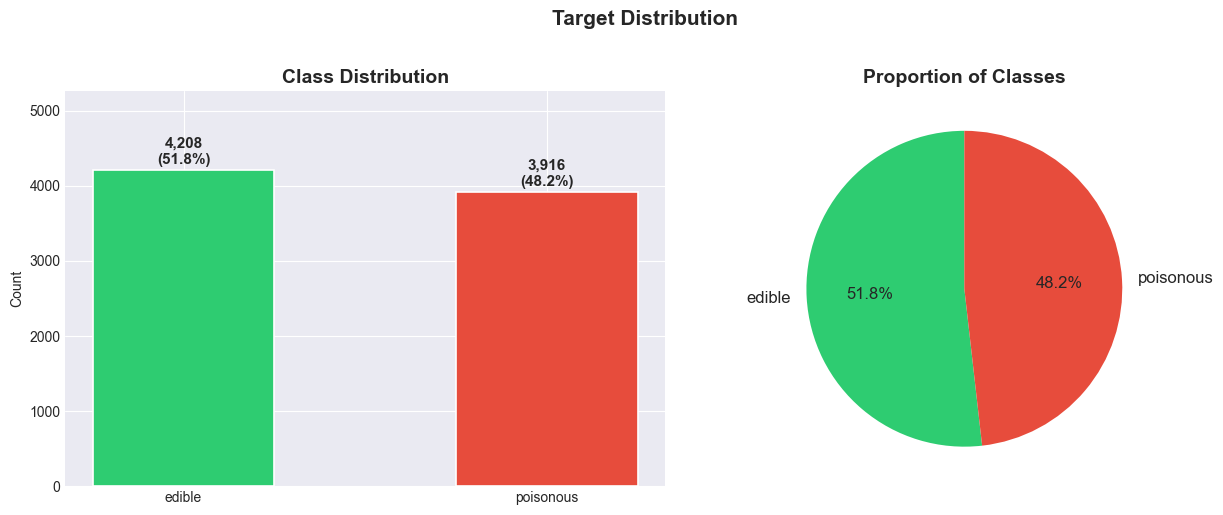

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

class_counts = df['class'].value_counts()
colors_cls = ['#2ecc71', '#e74c3c']

bars = axes[0].bar(class_counts.index, class_counts.values, color=colors_cls,
                   edgecolor='white', linewidth=1.2, width=0.5)
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, class_counts.max() * 1.25)

axes[1].pie(class_counts.values, labels=class_counts.index,
            colors=colors_cls, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Proportion of Classes', fontsize=14, fontweight='bold')
plt.suptitle('Target Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Nearly balanced — no need for oversampling. But since false negatives are deadly, Recall matters more than raw accuracy.

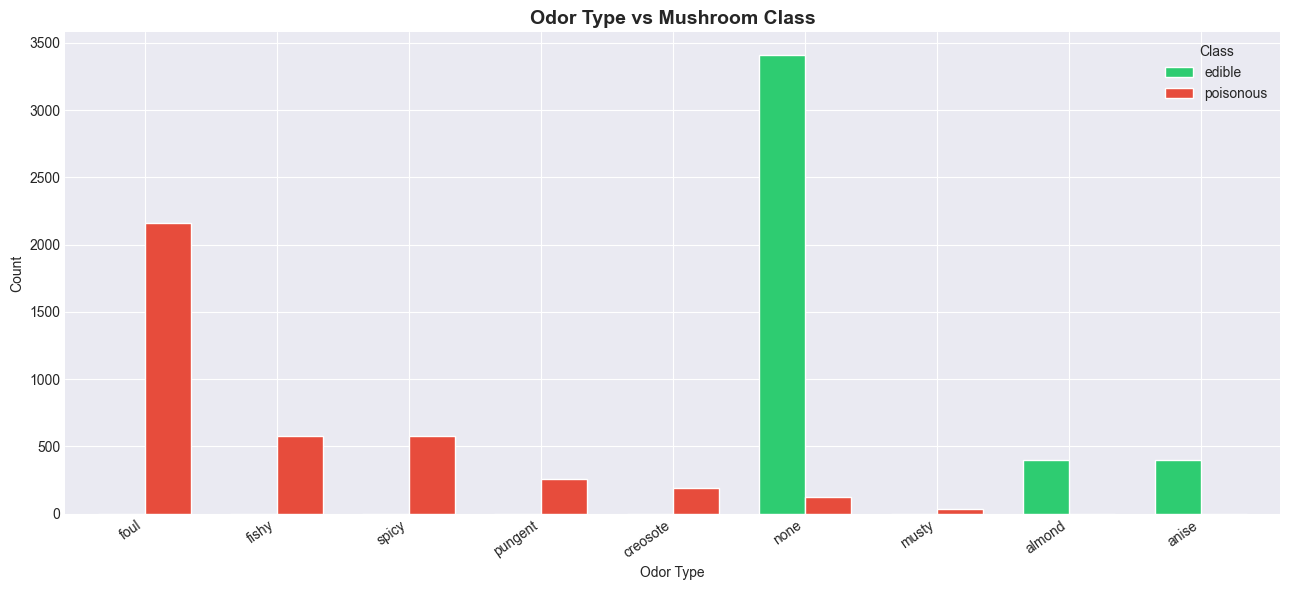


Poisonous rate by odor:
odor
creosote    100.0%
fishy       100.0%
foul        100.0%
musty       100.0%
pungent     100.0%
spicy       100.0%
none          3.4%
almond        0.0%
anise         0.0%


In [12]:
odor_class = df.groupby(['odor', 'class']).size().unstack(fill_value=0)
if 'poisonous' in odor_class.columns:
    odor_class = odor_class.loc[odor_class['poisonous'].sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(13, 6))
odor_class.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.7)
ax.set_title('Odor Type vs Mushroom Class', fontsize=14, fontweight='bold')
ax.set_xlabel('Odor Type'); ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
ax.legend(title='Class')
plt.tight_layout()
plt.show()

print('\nPoisonous rate by odor:')
pois_rate = df.groupby('odor')['class'].apply(lambda x: (x == 'poisonous').mean()).sort_values(ascending=False)
print(pois_rate.apply(lambda x: f'{x:.1%}').to_string())

Odor is the killer feature here — foul, creosote, fishy, spicy, pungent, and musty are all **100% poisonous**. Almond and anise are 100% edible. Only `none` is mixed (~3% poisonous). This single feature nearly solves the problem by itself.

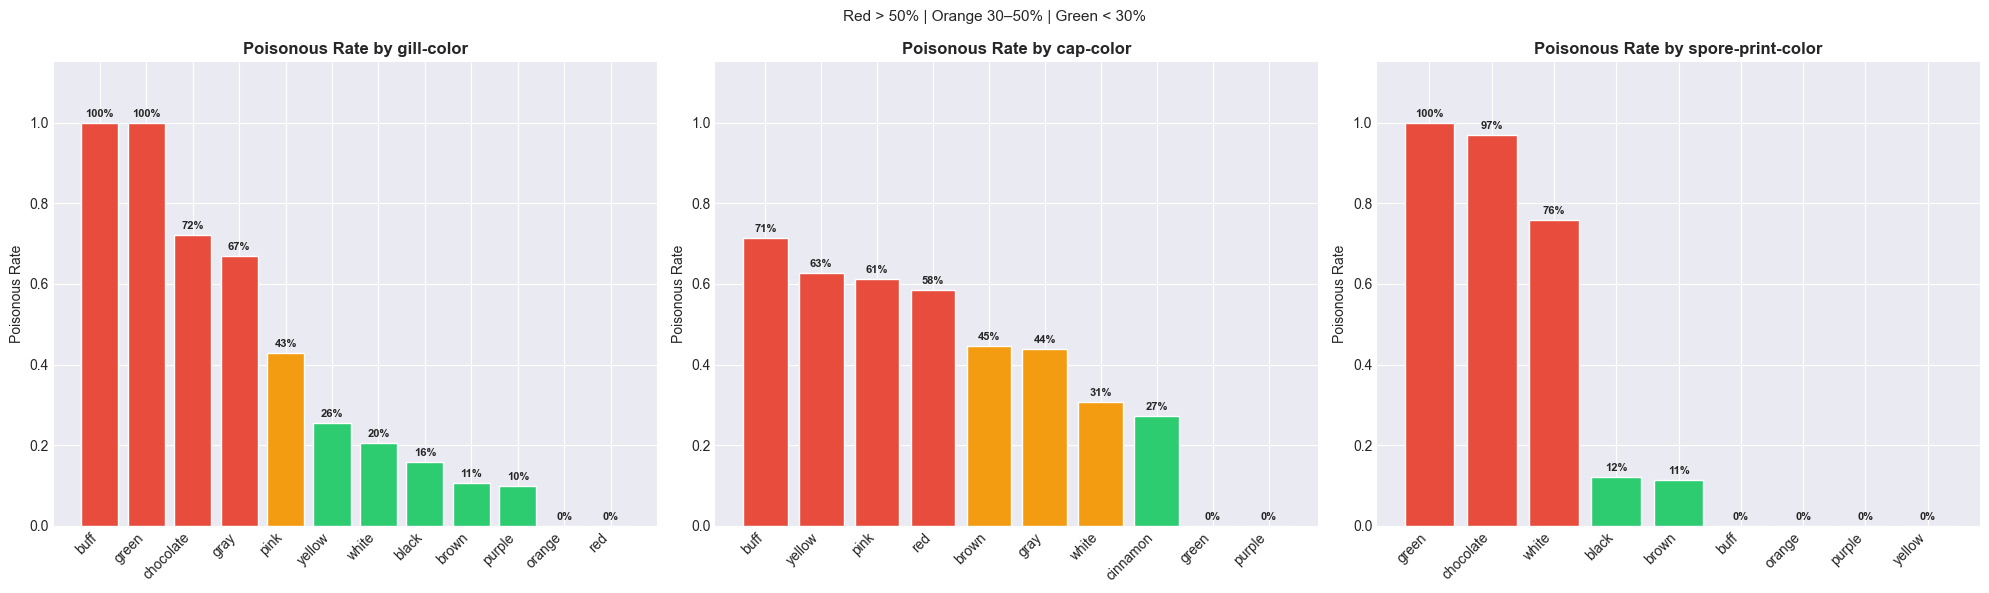

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, feature in zip(axes, ['gill-color', 'cap-color', 'spore-print-color']):
    pois = df.groupby(feature)['class'].apply(lambda x: (x == 'poisonous').mean()).sort_values(ascending=False)
    colors = ['#e74c3c' if v > 0.5 else '#2ecc71' if v < 0.3 else '#f39c12' for v in pois.values]
    bars = ax.bar(pois.index, pois.values, color=colors, edgecolor='white')
    for bar, val in zip(bars, pois.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.0%}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title(f'Poisonous Rate by {feature}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Poisonous Rate')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylim(0, 1.15)

plt.suptitle('Red > 50% | Orange 30–50% | Green < 30%', fontsize=11)
plt.tight_layout()
plt.show()

Some colors are strongly associated with being poisonous (e.g., green and buff gill colors). These aren't as decisive as odor but still add useful signal.


=== HABITAT ===
         Count  Edible  Poisonous  Poisonous %
habitat                                       
paths     1144     136       1008         88.1
urban      368      96        272         73.9
leaves     832     240        592         71.2
woods     3148    1880       1268         40.3
grasses   2148    1408        740         34.5
meadows    292     256         36         12.3
waste      192     192          0          0.0


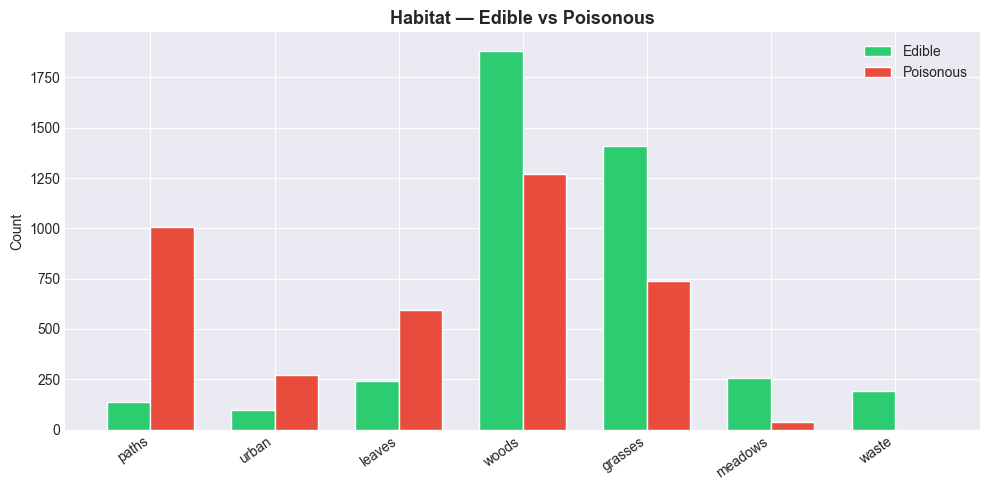


=== POPULATION ===
            Count  Edible  Poisonous  Poisonous %
population                                       
several      4040    1192       2848         70.5
solitary     1712    1064        648         37.9
scattered    1248     880        368         29.5
clustered     340     288         52         15.3
abundant      384     384          0          0.0
numerous      400     400          0          0.0


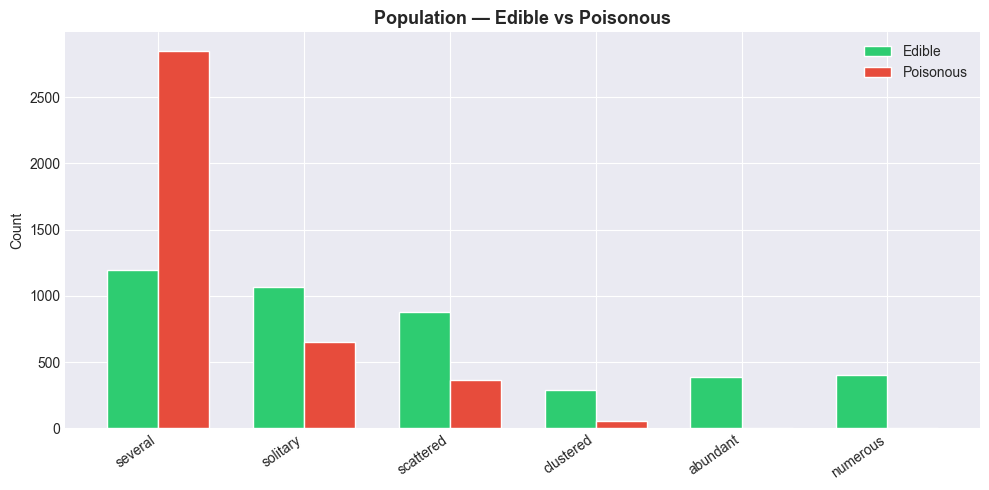

In [14]:
for feature in ['habitat', 'population']:
    agg = df.groupby(feature)['class'].agg(
        Count='count',
        Edible=lambda x: (x == 'edible').sum(),
        Poisonous=lambda x: (x == 'poisonous').sum()
    )
    agg['Poisonous %'] = (agg['Poisonous'] / agg['Count'] * 100).round(1)
    agg = agg.sort_values('Poisonous %', ascending=False)
    print(f'\n=== {feature.upper()} ===')
    print(agg.to_string())

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(agg)); w = 0.35
    ax.bar(x - w/2, agg['Edible'], width=w, label='Edible', color='#2ecc71', edgecolor='white')
    ax.bar(x + w/2, agg['Poisonous'], width=w, label='Poisonous', color='#e74c3c', edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(agg.index, rotation=35, ha='right')
    ax.set_title(f'{feature.title()} — Edible vs Poisonous', fontsize=13, fontweight='bold')
    ax.set_ylabel('Count'); ax.legend()
    plt.tight_layout(); plt.show()

Habitat and population show some differentiation between classes but nothing as dramatic as odor. They'll help as secondary features.

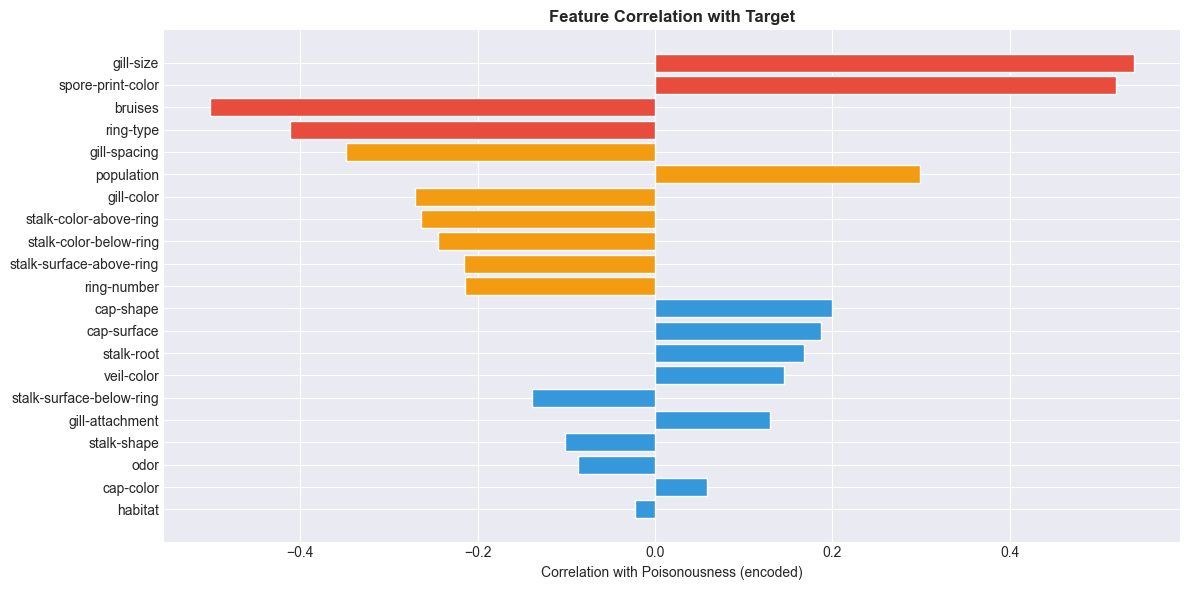

In [15]:
df_enc_temp = df.copy()
for col in df_enc_temp.columns:
    df_enc_temp[col] = LabelEncoder().fit_transform(df_enc_temp[col])

corr = df_enc_temp.corr()['class'].drop('class').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors_corr = ['#e74c3c' if abs(v) > 0.4 else '#f39c12' if abs(v) > 0.2 else '#3498db' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors_corr, edgecolor='white')
ax.set_xlabel('Correlation with Poisonousness (encoded)')
ax.set_title('Feature Correlation with Target', fontsize=12, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

del df_enc_temp

Confirms what we saw: odor dominates. Other useful features include gill-size, gill-color, spore-print-color, ring-type, and bruises.

## 5. Feature Engineering

In [ ]:
# has_odor — does the mushroom have any odor?
df['has_odor'] = (df['odor'] != 'none').astype(int)

# is_dangerous_odor — odors that are likely poisonous
dangerous_odors = ['creosote', 'foul', 'fishy', 'spicy', 'pungent', 'musty']
df['is_dangerous_odor'] = df['odor'].isin(dangerous_odors).astype(int)

# has_bruises
df['has_bruises'] = (df['bruises'] == 'yes').astype(int)

# stalk_root_unknown — missing root measurement
df['stalk_root_unknown'] = (df['stalk-root'] == 'unknown').astype(int)

print(f'Shape after engineering: {df.shape} (added 4 new features)')
print()
print('Dangerous odor vs class:')
print(df.groupby('is_dangerous_odor')['class'].value_counts(normalize=True).unstack())

Shape after engineering: (8124, 26) (added 4 new features)

Dangerous odor vs class:
class                edible  poisonous
is_dangerous_odor                     
0                  0.972274   0.027726
1                       NaN   1.000000


All four features are grounded in EDA findings:
- `is_dangerous_odor` perfectly captures the 6 odor types that are likely poisonous.
- `has_odor` separates the "no odor" group (mostly edible) from everything else.
- `has_bruises` reflects the pattern that edible mushrooms bruise more.
- `stalk_root_unknown` flags the 30% of mushrooms with missing root data.

## 6. Preprocessing

In [17]:
# Define X and y
X = df.drop(columns=['class'])
y = (df['class'] == 'poisonous').astype(int)  # 1 = poisonous, 0 = edible
print(f'X shape: {X.shape}')
print(f'y: edible={(y==0).sum()}, poisonous={(y==1).sum()}')

X shape: (8124, 25)
y: edible=4208, poisonous=3916


In [18]:
# One-hot encode using get_dummies (no fit = no leakage risk)
X_encoded = pd.get_dummies(X, drop_first=True)
print(f'After encoding: {X_encoded.shape}')

After encoding: (8124, 99)


In [19]:
# Train-test split (stratified, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)
print(f'X_train: {X_train.shape}  X_test: {X_test.shape}')
print(f'Train balance: {pd.Series(y_train).value_counts().to_dict()}')
print(f'Test balance:  {pd.Series(y_test).value_counts().to_dict()}')

X_train: (6499, 99)  X_test: (1625, 99)
Train balance: {0: 3366, 1: 3133}
Test balance:  {0: 842, 1: 783}


In [20]:
# No scaling — tree models are scale-invariant, KNN operates on binary features
# Define shared CV strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Quick sanity check
assert X_train.isnull().sum().sum() == 0
assert X_test.isnull().sum().sum() == 0
print('Preprocessing done. No nulls, no leakage.')

Preprocessing done. No nulls, no leakage.


Used `get_dummies` (stateless — no fit) so there's zero data leakage. No scaling needed since all our models are tree-based (+ KNN on binary features). Stratified split keeps class balance.

## 7. Baseline Model + Cross-Validation

In [21]:
baseline_dt = DecisionTreeClassifier(random_state=42)

print('=== Baseline Decision Tree — 5-Fold Stratified CV (training data only) ===\n')
for metric in ['accuracy', 'precision', 'recall', 'f1']:
    scores = cross_val_score(baseline_dt, X_train, y_train, cv=cv, scoring=metric, n_jobs=-1)
    print(f'{metric:12s}: {scores.mean():.4f} ± {scores.std():.4f}  |  folds: {[round(s,4) for s in scores]}')

=== Baseline Decision Tree — 5-Fold Stratified CV (training data only) ===

accuracy    : 0.9997 ± 0.0006  |  folds: [np.float64(0.9985), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
precision   : 1.0000 ± 0.0000  |  folds: [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
recall      : 0.9994 ± 0.0013  |  folds: [np.float64(0.9968), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
f1          : 0.9997 ± 0.0006  |  folds: [np.float64(0.9984), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]


=== Test Set Results ===

              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       842
   Poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



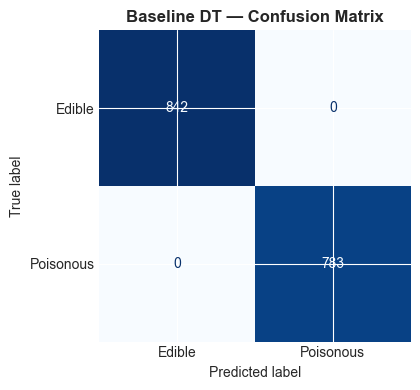


False Negatives (poisonous → edible): 0  ← DANGEROUS
False Positives (edible → poisonous): 0


In [22]:
# Evaluate on test set
baseline_dt.fit(X_train, y_train)
y_pred_base = baseline_dt.predict(X_test)

print('=== Test Set Results ===\n')
print(classification_report(y_test, y_pred_base, target_names=['Edible', 'Poisonous']))

cm_base = confusion_matrix(y_test, y_pred_base)
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay(cm_base, display_labels=['Edible', 'Poisonous']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Baseline DT — Confusion Matrix', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'\nFalse Negatives (poisonous → edible): {cm_base[1][0]}  ← DANGEROUS')
print(f'False Positives (edible → poisonous): {cm_base[0][1]}')

Even the default Decision Tree performs very well — odor basically solves the problem. The key number to watch is False Negatives: those are the poisonous mushrooms that slip through.

## 8. Hyperparameter Tuning — Decision Tree

We optimize for `recall` because false negatives are life-threatening.

In [23]:
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

print(f'Grid: {6*4*4*2} combos × 5 folds = {6*4*4*2*5} fits')

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42), param_grid_dt,
    cv=cv, scoring='recall', n_jobs=-1, verbose=1
)
grid_dt.fit(X_train, y_train)

print(f'\nBest params: {grid_dt.best_params_}')
print(f'Best CV Recall: {grid_dt.best_score_:.4f}')

Grid: 192 combos × 5 folds = 960 fits
Fitting 5 folds for each of 192 candidates, totalling 960 fits

Best params: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Recall: 0.9994


=== Tuned DT — Test Set ===

              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       842
   Poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



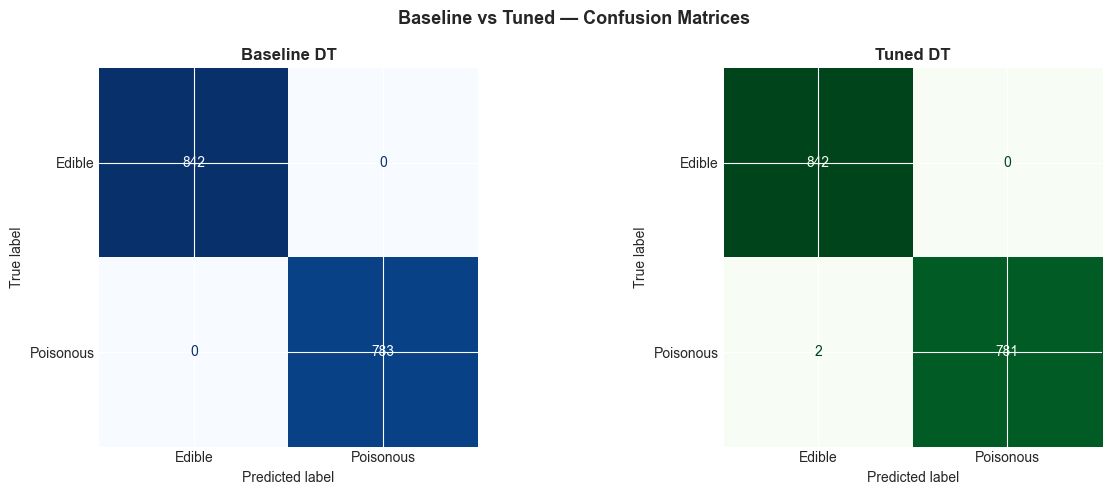

Baseline FN: 0 → Tuned FN: 2
Baseline FP: 0 → Tuned FP: 0


In [24]:
best_dt = grid_dt.best_estimator_
y_pred_dt_tuned = best_dt.predict(X_test)

print('=== Tuned DT — Test Set ===\n')
print(classification_report(y_test, y_pred_dt_tuned, target_names=['Edible', 'Poisonous']))

cm_dt_tuned = confusion_matrix(y_test, y_pred_dt_tuned)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay(cm_base, display_labels=['Edible', 'Poisonous']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Baseline DT', fontweight='bold')
ConfusionMatrixDisplay(cm_dt_tuned, display_labels=['Edible', 'Poisonous']).plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Tuned DT', fontweight='bold')
plt.suptitle('Baseline vs Tuned — Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'Baseline FN: {cm_base[1][0]} → Tuned FN: {cm_dt_tuned[1][0]}')
print(f'Baseline FP: {cm_base[0][1]} → Tuned FP: {cm_dt_tuned[0][1]}')

Tuning may or may not improve things much — the dataset is almost perfectly separable by odor. Check whether FN went down.

## 9. Additional Models

### 9.1 Random Forest

RF (default) CV Recall: 0.9994 ± 0.0013
Best params: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Best CV Recall: 0.9997

              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       842
   Poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



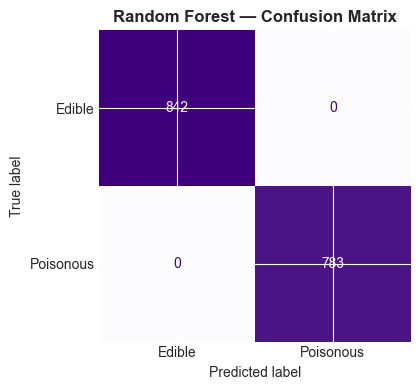

In [25]:
rf_default = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_cv = cross_val_score(rf_default, X_train, y_train, cv=cv, scoring='recall', n_jobs=-1)
print(f'RF (default) CV Recall: {rf_cv.mean():.4f} ± {rf_cv.std():.4f}')

rsearch_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    {'n_estimators': [50, 100, 200, 300], 'max_depth': [None, 5, 10, 20],
     'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 5],
     'max_features': ['sqrt', 'log2']},
    n_iter=20, cv=cv, scoring='recall', random_state=42, n_jobs=-1
)
rsearch_rf.fit(X_train, y_train)
best_rf = rsearch_rf.best_estimator_
print(f'Best params: {rsearch_rf.best_params_}')
print(f'Best CV Recall: {rsearch_rf.best_score_:.4f}')

y_pred_rf = best_rf.predict(X_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)
print()
print(classification_report(y_test, y_pred_rf, target_names=['Edible', 'Poisonous']))

fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay(cm_rf, display_labels=['Edible', 'Poisonous']).plot(ax=ax, cmap='Purples', colorbar=False)
ax.set_title('Random Forest — Confusion Matrix', fontweight='bold')
plt.tight_layout(); plt.show()

Random Forest ensembles many trees, which usually gives more stable predictions and often matches or beats a single tuned tree.

### 9.2 Gradient Boosting

GB (default) CV Recall: 0.9994 ± 0.0013
Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV Recall: 0.9994

              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       842
   Poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



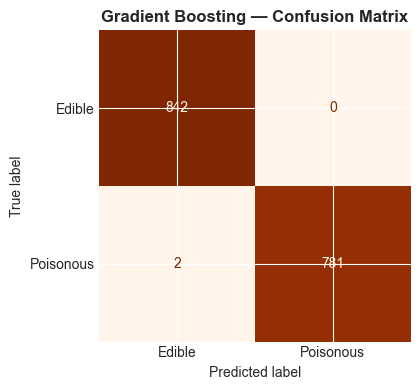

In [26]:
gb_default = GradientBoostingClassifier(random_state=42)
gb_cv = cross_val_score(gb_default, X_train, y_train, cv=cv, scoring='recall', n_jobs=-1)
print(f'GB (default) CV Recall: {gb_cv.mean():.4f} ± {gb_cv.std():.4f}')

grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1, 0.2],
     'max_depth': [3, 5], 'subsample': [0.8, 1.0]},
    cv=cv, scoring='recall', n_jobs=-1
)
grid_gb.fit(X_train, y_train)
best_gb = grid_gb.best_estimator_
print(f'Best params: {grid_gb.best_params_}')
print(f'Best CV Recall: {grid_gb.best_score_:.4f}')

y_pred_gb = best_gb.predict(X_test)
cm_gb = confusion_matrix(y_test, y_pred_gb)
print()
print(classification_report(y_test, y_pred_gb, target_names=['Edible', 'Poisonous']))

fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay(cm_gb, display_labels=['Edible', 'Poisonous']).plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title('Gradient Boosting — Confusion Matrix', fontweight='bold')
plt.tight_layout(); plt.show()

Boosting builds trees sequentially to correct errors. It's usually strong but can overfit small datasets.

### 9.3 KNN

KNN (default) CV Recall: 0.9987 ± 0.0026
Best params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best CV Recall: 1.0000

              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       842
   Poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



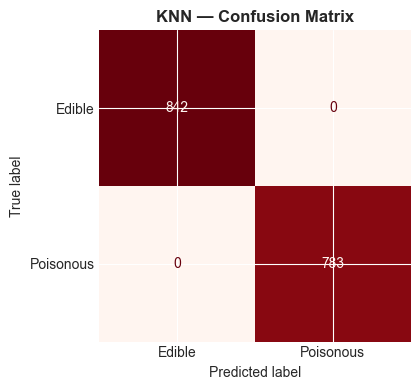

In [27]:
knn_default = KNeighborsClassifier()
knn_cv = cross_val_score(knn_default, X_train, y_train, cv=cv, scoring='recall', n_jobs=-1)
print(f'KNN (default) CV Recall: {knn_cv.mean():.4f} ± {knn_cv.std():.4f}')

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors': [3, 5, 7, 10, 15], 'weights': ['uniform', 'distance'],
     'metric': ['euclidean', 'manhattan']},
    cv=cv, scoring='recall', n_jobs=-1
)
grid_knn.fit(X_train, y_train)
best_knn = grid_knn.best_estimator_
print(f'Best params: {grid_knn.best_params_}')
print(f'Best CV Recall: {grid_knn.best_score_:.4f}')

y_pred_knn = best_knn.predict(X_test)
cm_knn = confusion_matrix(y_test, y_pred_knn)
print()
print(classification_report(y_test, y_pred_knn, target_names=['Edible', 'Poisonous']))

fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay(cm_knn, display_labels=['Edible', 'Poisonous']).plot(ax=ax, cmap='Reds', colorbar=False)
ax.set_title('KNN — Confusion Matrix', fontweight='bold')
plt.tight_layout(); plt.show()

KNN on one-hot binary features — performance depends heavily on k and distance metric.

## 10. Model Comparison

In [28]:
models_eval = {
    'DT (baseline)':  (baseline_dt,  y_pred_base),
    'DT (tuned)':     (best_dt,      y_pred_dt_tuned),
    'Random Forest':  (best_rf,      y_pred_rf),
    'Grad. Boosting': (best_gb,      y_pred_gb),
    'KNN':            (best_knn,     y_pred_knn),
}

results = []
for name, (model, y_pred) in models_eval.items():
    cm_m = confusion_matrix(y_test, y_pred)
    cv_rec = cross_val_score(model, X_train, y_train, cv=cv, scoring='recall', n_jobs=-1)
    results.append({
        'Model': name,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1':        round(f1_score(y_test, y_pred), 4),
        'CV Recall': round(cv_rec.mean(), 4),
        'CV Std':    round(cv_rec.std(), 4),
        'FN': int(cm_m[1][0]),
        'FP': int(cm_m[0][1]),
    })

results_df = pd.DataFrame(results).sort_values('Recall', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

         Model  Accuracy  Precision  Recall     F1  CV Recall  CV Std  FN  FP
 DT (baseline)    1.0000        1.0  1.0000 1.0000     0.9994  0.0013   0   0
 Random Forest    1.0000        1.0  1.0000 1.0000     0.9997  0.0006   0   0
           KNN    1.0000        1.0  1.0000 1.0000     1.0000  0.0000   0   0
    DT (tuned)    0.9988        1.0  0.9974 0.9987     0.9994  0.0013   2   0
Grad. Boosting    0.9988        1.0  0.9974 0.9987     0.9994  0.0013   2   0


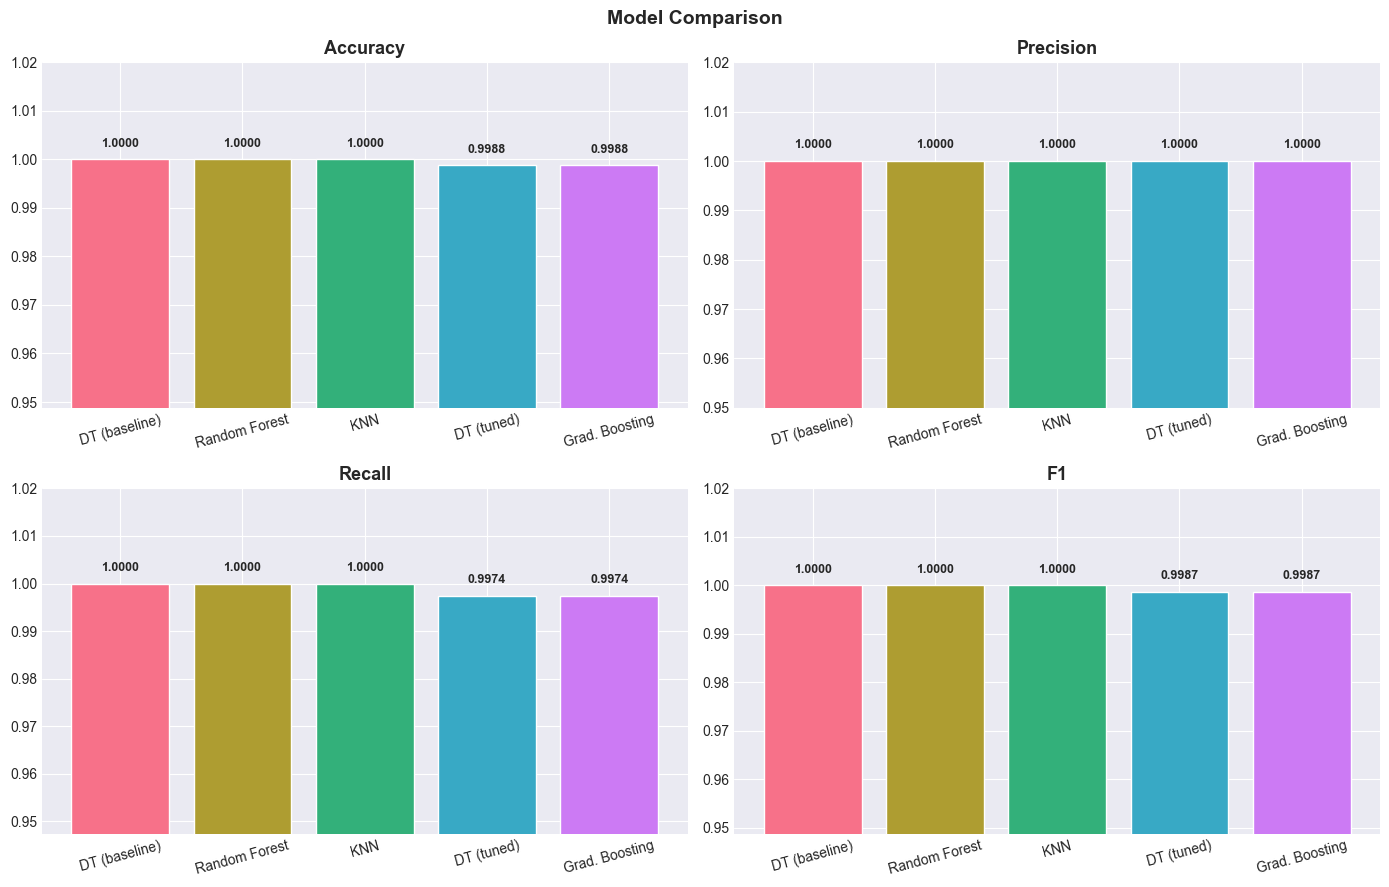

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, metric in zip(axes.flatten(), ['Accuracy', 'Precision', 'Recall', 'F1']):
    vals = results_df[metric].values
    bars = ax.bar(results_df['Model'], vals, color=sns.color_palette('husl', len(vals)), edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(min(vals) - 0.05, 1.02)
    ax.tick_params(axis='x', rotation=15)
plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

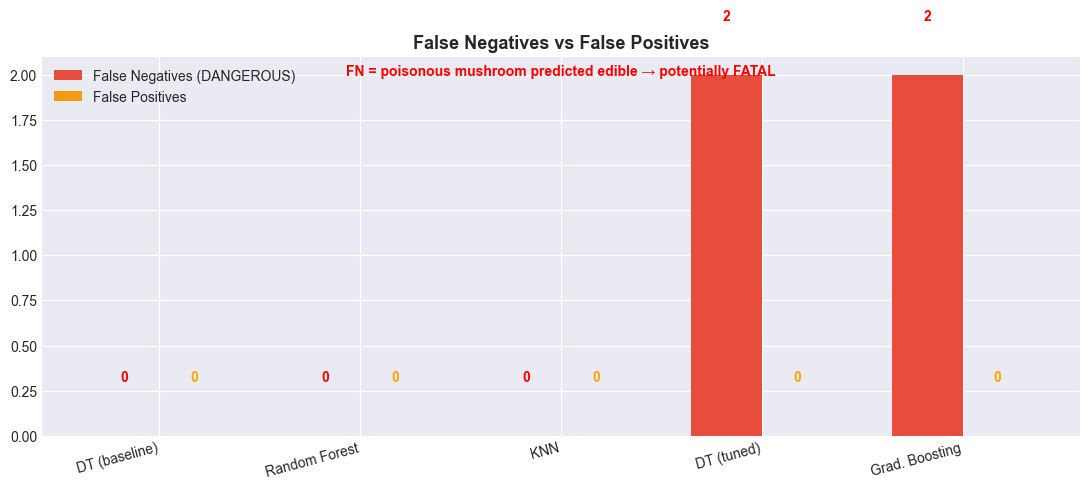

In [30]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(results_df)); w = 0.35
ax.bar(x - w/2, results_df['FN'], width=w, label='False Negatives (DANGEROUS)', color='#e74c3c')
ax.bar(x + w/2, results_df['FP'], width=w, label='False Positives', color='#f39c12')
for i, (fn, fp) in enumerate(zip(results_df['FN'], results_df['FP'])):
    ax.text(i - w/2, fn + 0.3, str(fn), ha='center', fontweight='bold', color='red')
    ax.text(i + w/2, fp + 0.3, str(fp), ha='center', fontweight='bold', color='orange')
ax.set_xticks(x); ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax.set_title('False Negatives vs False Positives', fontsize=13, fontweight='bold')
ax.legend()
ax.annotate('FN = poisonous mushroom predicted edible → potentially FATAL',
            xy=(0.5, 0.95), xycoords='axes fraction', ha='center', fontsize=10, color='red', fontweight='bold')
plt.tight_layout(); plt.show()

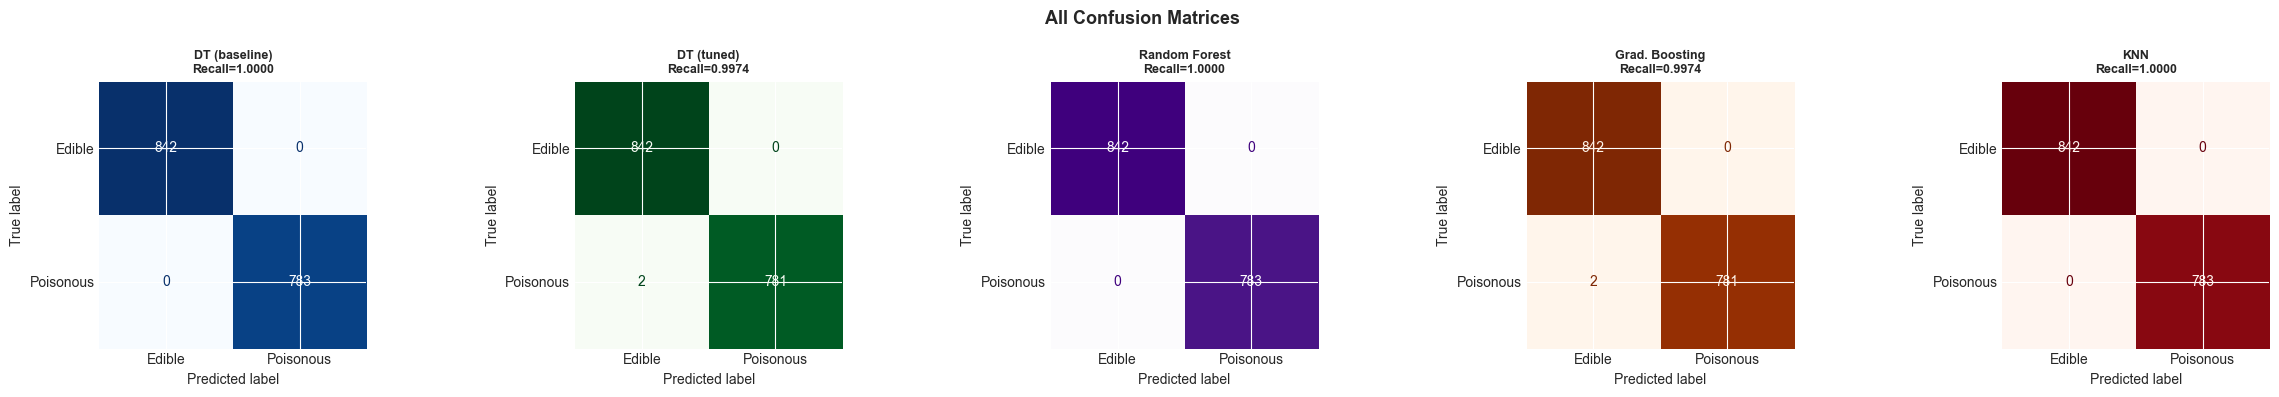

In [31]:
fig, axes = plt.subplots(1, 5, figsize=(24, 4))
cmaps = ['Blues', 'Greens', 'Purples', 'Oranges', 'Reds']
for ax, (name, (model, y_pred)), cmap in zip(axes, models_eval.items(), cmaps):
    cm_m = confusion_matrix(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    ConfusionMatrixDisplay(cm_m, display_labels=['Edible', 'Poisonous']).plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(f'{name}\nRecall={rec:.4f}', fontsize=9, fontweight='bold')
plt.suptitle('All Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

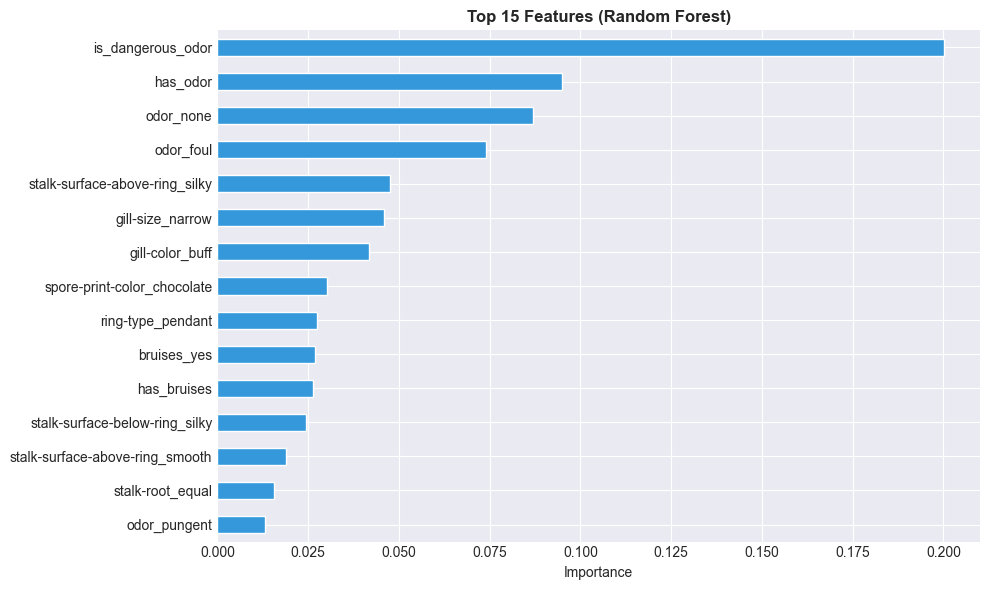

In [32]:
feat_imp = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.sort_values().plot(kind='barh', ax=ax, color='#3498db', edgecolor='white')
ax.set_xlabel('Importance'); ax.set_title('Top 15 Features (Random Forest)', fontweight='bold')
plt.tight_layout(); plt.show()

In [33]:
print('=== Per-Model Summary ===\n')
total_p = (y_test == 1).sum()
for _, row in results_df.iterrows():
    fn, fp = int(row['FN']), int(row['FP'])
    print(f"{row['Model']}")
    print(f"  Recall={row['Recall']:.4f} → caught {total_p - fn}/{total_p} poisonous")
    print(f"  FN={fn} (would be eaten), FP={fp} (discarded)")
    print()

=== Per-Model Summary ===

DT (baseline)
  Recall=1.0000 → caught 783/783 poisonous
  FN=0 (would be eaten), FP=0 (discarded)

Random Forest
  Recall=1.0000 → caught 783/783 poisonous
  FN=0 (would be eaten), FP=0 (discarded)

KNN
  Recall=1.0000 → caught 783/783 poisonous
  FN=0 (would be eaten), FP=0 (discarded)

DT (tuned)
  Recall=0.9974 → caught 781/783 poisonous
  FN=2 (would be eaten), FP=0 (discarded)

Grad. Boosting
  Recall=0.9974 → caught 781/783 poisonous
  FN=2 (would be eaten), FP=0 (discarded)



**Takeaways:**
- All models perform very well because `odor` nearly solves the problem.
- The best model is the one with the **fewest False Negatives** (highest Recall) — that's the safest choice.
- Feature importance confirms odor-related features dominate.
- The dataset is small and from a specific context, so these near-perfect results may not generalize to real-world foraging without more diverse data.